In [ ]:
#Setup and imports
import os
# 1) cd into your repo root (where `astronet/` lives)
os.chdir('Astronet-Triage')
print('In folder:', os.getcwd())

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from astronet import models, evaluation
from astronet.util import config_util

# Adjust these paths:
model_dir = '../mnt/tess/models/vetting/20250429/cshallue/AstroCNNModelVetting_cshallue_20250429_181612'

test_tfrecord_pattern = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/*'


# test_tfrecord_pattern = '/pdo/astronet-data/data/tfrecords/sector-87/000**-of-00025'

live_sector=False

# test_tfrecord_pattern = '../../dimond/mnt/tess/astronet/tfrecords-vetting-sector86-all-test/*'
# live_sector=True

# # (optional) path to the original CSV of labels, for more detailed analysis:
# tces_csv = '../mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-april2025-test.csv'

print(os.getcwd())

In folder: /pdo/users/pablomer/Astronet-Triage


2025-07-07 23:39:06.697681: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-07 23:39:08.048875: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/pdo/users/pablomer/Astronet-Triage


In [2]:
# Cell 2: Load configs & model
from astronet.util import config_util

train_flags = config_util.load_config(os.path.join(model_dir, 'train_flags.json'))
config      = config_util.load_config(os.path.join(model_dir, 'config.json'))

# load the model
model_name = train_flags['model']
# model = models.load_model(model_name, model_dir)
with tf.device('/CPU:0'):
    model = models.load_model(model_name, model_dir)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


2025-07-07 23:39:23.155218: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46672 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:05:00.0, compute capability: 8.6
2025-07-07 23:39:23.157276: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46672 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6
2025-07-07 23:39:23.159080: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 46672 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:45:00.0, compute capability: 8.6
2025-07-07 23:39:23.160689: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 46672 MB memory:  -> device: 3, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, 

Model: "astro_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_block (ConvBlock)      (None, 12852)             9095      
                                                                 
 conv_block_1 (ConvBlock)    (None, 1280)              7936      
                                                                 
 conv_block_6 (ConvBlock)    (None, 464)               2848      
                                                                 
 conv_block_2 (ConvBlock)    (None, 2752)              8272      
                                                                 
 conv_block_5 (ConvBlock)    (None, 612)               85731     
                                                                 
 conv_block_4 (ConvBlock)    (None, 4080)              84813     
                                                                 
 conv_block_3 (ConvBlock)    (None, 2752)          

In [3]:
# # Cell: Inspect TFRecord features to check for labels

# import os
# import tensorflow as tf
# from astronet.util import config_util

# # Adjust these paths as needed
# model_dir = '../mnt/tess/models/vetting/20250429/cshallue/AstroCNNModelVetting_cshallue_20250429_181612'
# tfrecord_pattern = '../../dimond/mnt/tess/astronet/tfrecords-vetting-sector86-all-test/*'

# # Load config so we know which label columns to expect
# config = config_util.load_config(os.path.join(model_dir, 'config.json'))
# expected_labels = config.inputs.label_columns

# # Read a few raw tf.Example protos
# files = tf.io.gfile.glob(tfrecord_pattern)
# raw_dataset = tf.data.TFRecordDataset(files)
# raw_examples = list(raw_dataset.take(5).as_numpy_iterator())

# # Parse each ExampleProto and collect all feature keys seen
# feature_sets = []
# for raw in raw_examples:
#     ex = tf.train.Example()
#     ex.ParseFromString(raw)
#     feature_sets.append(set(ex.features.feature.keys()))

# all_keys = set.union(*feature_sets)
# print("Features present in these TFRecords:")
# for key in sorted(all_keys):
#     print("  ", key)

# # Check which expected label fields are present
# found = [lbl for lbl in expected_labels if lbl in all_keys]
# if found:
#     print("\n✔ Label features found:", found)
# else:
#     print("\n✘ None of the expected label columns were found:", expected_labels)


In [4]:
#Get both preds and true labels + IDs

from astronet.astro_cnn_model import input_ds
import numpy as np

batch_size = config.hparams.batch_size

# 1) Build dataset for predictions (drops labels, keeps IDs)
ds_pred = input_ds.build_eval_dataset(
    file_pattern=test_tfrecord_pattern,
    input_config=config.inputs,
    batch_size=batch_size,
    include_identifiers=True,
    include_labels=False
)
with tf.device('/CPU:0'):
    preds = model.predict(ds_pred)     # shape (N, C)

# # Get the IDs
# ids = []
# for batch in ds_pred:
#     ids.append(batch[1].numpy())  # batch[1] is 'astro_id'
# ids = np.concatenate(ids)
# # Get the true labels


2025-07-07 23:39:32.548593: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [25]
	 [[{{node Placeholder/_0}}]]


10/10 [==============================] - 1s 80ms/step


In [5]:
if not live_sector:
    # 2) Build dataset for labels + IDs (no shuffling!)
    ds_lbl = input_ds.build_eval_dataset(
        file_pattern=test_tfrecord_pattern,
        input_config=config.inputs,
        batch_size=batch_size,
        include_identifiers=True,
        include_labels=True
    )

    labels_list = []
    ids_list    = []
    for features, labels_batch, weight_batch, id_batch in ds_lbl:
        # labels_batch: (batch, C), id_batch: (batch,)
        labels_list.append(labels_batch.numpy())
        ids_list.append(id_batch.numpy())

    labels    = np.concatenate(labels_list, axis=0)    # (N, C)
    astro_ids = np.concatenate(ids_list,    axis=0)    # (N,)

    print("preds shape:   ", preds.shape)
    print("labels shape:  ", labels.shape)
    print("astro_ids shape:", astro_ids.shape)

if live_sector:
    import pandas as pd

    astro_ids = []
    tic_ids = []
    planet_nos = []
    model_nos = []
    for batch in ds_pred:
        inputs, identifiers = batch
        astro_ids.extend([x for x in identifiers.numpy()])
        tic_ids = [int(str(x)[:-2]) for x in astro_ids]
        planet_nos = [int(str(x)[-2:]) for x in astro_ids]
        model_nos = [0 for x in astro_ids]

    df = pd.DataFrame(preds, columns=["disp_p", "disp_e", "disp_n", "disp_j"])
    df.insert(0,"model_no", model_nos)
    df.insert(0,"planetno", planet_nos)
    df.insert(0, "tic_id", tic_ids)
    df.insert(0, "Astro ID", astro_ids)


    # Load the true labels from the CSV file
    # 1. Load and preprocess the true labels
    true_labels_csv_path= '/pdo/users/dimond/eval_test/pablo_model/test_predictions_with_label.csv'
    true_labels_df = pd.read_csv(
        true_labels_csv_path
    )[['astro_id','true_label']]
    true_labels_column = true_labels_df['true_label']

    print("Using labels loaded from CSV file:", true_labels_csv_path)

    def convert_to_one_hot(label):
        if label == 'p': return [1, 0, 0, 0]
        if label == 'e': return [0, 1, 0, 0]
        if label == 'n': return [0, 0, 1, 0]
        if label == 'j': return [0, 0, 0, 1]
        return None

    true_labels_df['one_hot'] = true_labels_df['true_label'].apply(convert_to_one_hot)
    true_labels_df = true_labels_df.drop(columns='true_label')


    #check if true_labels_df['astro_id'] == df['Astro ID']
    # 4. Check if the IDs match
    # Check if the IDs match
    ids_match = np.array_equal(
        true_labels_df['astro_id'].values,
        df['Astro ID'].values
    )

    if ids_match:
        print("IDs match!")
    else:
        print("Warning: IDs do not match!")


    # 3. Align and extract the labels in the exact same order as df
    #    This will give you an array of shape (N,4)
    labels = np.array(true_labels_df['one_hot'].tolist())

    # now `labels` is a NumPy array you can feed into your metrics functions
    print('Labels shape:',labels.shape)  # e.g. (num_examples, 4)


2025-07-07 23:39:36.876351: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [25]
	 [[{{node Placeholder/_0}}]]
2025-07-07 23:39:36.967483: W tensorflow/core/framework/op_kernel.cc:1830] OP_REQUIRES failed at example_parsing_ops.cc:98 : INVALID_ARGUMENT: Feature: disp_e (data type: int64) is required but could not be found.
2025-07-07 23:39:36.967600: W tensorflow/core/framework/op_kernel.cc:1830] OP_REQUIRES failed at example_parsing_ops.cc:98 : INVALID_ARGUMENT: Feature: disp_e (data type: int64) is required but could not be found.
2025-07-07 23:39:36.967706: I tensorflow/core/common_runtime/executor.cc:1197] [/job:localhost/replica:0/task:0/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): 

InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_62_device_/job:localhost/replica:0/task:0/device:CPU:0}} Feature: disp_e (data type: int64) is required but could not be found.
	 [[{{node ParseSingleExample/ParseExample/ParseExampleV2}}]] [Op:IteratorGetNext]

In [7]:
# Optional: Save the predictions and true labels to a CSV file

# Concatenate df and true_labels_column
# data_table = pd.concat([df, true_labels_column], axis=1)
# data_table.head()
# # Save the DataFrame to a CSV file
# output_csv_path = '/pdo/users/pablomer/mnt/tess/sector_86_predictions.csv'
# data_table.to_csv(output_csv_path, index=False)


In [8]:
# Count how many times true_label is 'p'
count_p = (true_labels_column == 'p').sum()
print(count_p)
# Count how many times max predictions is 'p'
count_max_p = (df['disp_p'] == df[['disp_p', 'disp_e', 'disp_n', 'disp_j']].max(axis=1)).sum()
print(count_max_p)

NameError: name 'true_labels_column' is not defined

In [8]:
# # Cell X: Verify that ds_pred and ds_lbl are in the same order via astro_id

# from astronet.astro_cnn_model import input_ds
# import numpy as np

# # Build both datasets _with_ identifiers
# ds_pred_ids = input_ds.build_eval_dataset(
#     file_pattern=test_tfrecord_pattern,
#     input_config=config.inputs,
#     batch_size=batch_size,
#     include_identifiers=True,
#     include_labels=False
# )
# ds_lbl_ids = input_ds.build_eval_dataset(
#     file_pattern=test_tfrecord_pattern,
#     input_config=config.inputs,
#     batch_size=batch_size,
#     include_identifiers=True,
#     include_labels=True
# )

# # Extract and concatenate astro_id batches
# ids_pred = np.concatenate([rec[-1].numpy() for rec in ds_pred_ids], axis=0)
# ids_lbl  = np.concatenate([rec[-1].numpy() for rec in ds_lbl_ids],  axis=0)

# # Quick sanity prints
# print("First 10 IDs in preds:", ids_pred[:10])
# print("First 10 IDs in labels:", ids_lbl[:10])

# # Assert they’re identical
# assert np.array_equal(ids_pred, ids_lbl), "🚨 Dataset ordering mismatch!"
# print(f"✅ Datasets aligned across {len(ids_pred)} examples.")


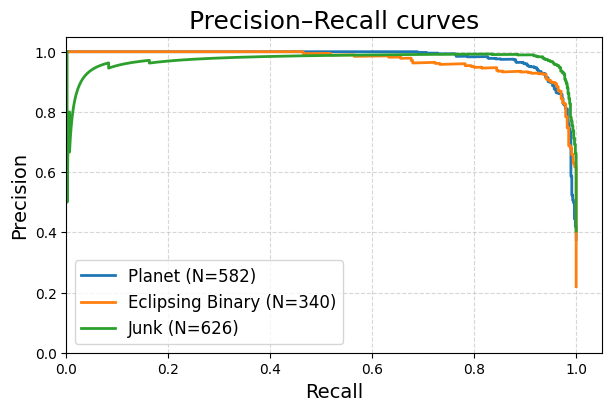

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
)
# import scienceplots


test_labels = labels
test_pred   = preds

# drop the “Not Sure” column
test_labels = np.delete(test_labels, 2, axis=1)
test_pred   = np.delete(test_pred,   2, axis=1)


if live_sector:
    test_labels = np.delete(test_labels, 1, axis=1)
    test_pred   = np.delete(test_pred,   1, axis=1)
    label_names = ["Planet", "Junk"]
else:
    label_names = ["Planet", "Eclipsing Binary", "Junk"]

counts = test_labels.sum(axis=0).astype(int)

# ─── 1) compute PR for each class ────────────────────────────────────────
pr_data = []
for i in range(len(label_names)):
    y_true  = test_labels[:, i]
    y_score = test_pred[:,   i]
    p, r, t  = precision_recall_curve(y_true, y_score)
    ap       = average_precision_score(y_true, y_score)
    pr_data.append({
        "precision": p,
        "recall":    r,
        "thresholds":t,
        "ap":        ap
    })

# ─── 2) plot all three curves ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)

lines = []
for i, name in enumerate(label_names):
    data = pr_data[i]
    lbl  = f"{name} (N={counts[i]})"
    ln, = ax.plot(data["recall"][:-1],
                  data["precision"][:-1],
                  lw=2, label=lbl)
    lines.append(ln)

ax.set_xlabel("Recall",    fontsize=14)
ax.set_ylabel("Precision", fontsize=14)
ax.set_title("Precision–Recall curves", fontsize=18)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)

# ─── 3) add interactive annotation ───────────────────────────────────────
annot = ax.annotate(
    "",
    xy=(0,0), xytext=(-40,-20),
    textcoords="offset points",
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.5", fc="w", alpha=0.9, clip_on=False),
    arrowprops=dict(arrowstyle="->")
)
annot.set_visible(False)

def update_annot(class_idx, ind):
    idx = ind["ind"][0]
    d   = pr_data[class_idx]
    annot.xy = (d["recall"][idx], d["precision"][idx])
    annot.set_text(
        f"{label_names[class_idx]}\n"
        f"Precision = {d['precision'][idx]:.3f}\n"
        f"Recall = {d['recall'][idx]:.3f}\n"
        f"Threshold = {d['thresholds'][idx]:.3f}"
    )

def onclick(event):
    if event.inaxes != ax:
        return
    for i, ln in enumerate(lines):
        hit, ind = ln.contains(event)
        if hit:
            update_annot(i, ind)
            annot.set_visible(True)
            fig.canvas.draw_idle()
            return
    # click elsewhere hides the box
    if annot.get_visible():
        annot.set_visible(False)
        fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", onclick)

# ─── 4) legend & show ───────────────────────────────────────────────────
ax.legend(loc="lower left", fontsize=12, framealpha=0.8)
plt.show()

# ─── 5) extra diagnostics (optional) ────────────────────────────────────
# You can still compute confusion matrices, ROC, etc., exactly as before.
